In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent ))

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

In [3]:
from src.dominick import DominickDataLoader
from src.dominick.multiproduct_builder import MultiProductBuilder
from src.nn.data import ColumnEncoder, DataLoaderFactory, SplineBuilder
from src.nn.spline import CubicSplineBasis
from src.nn.models import IntegrableDemandHead, ICDN
from src.nn.loss import ElasticityLoss
from src.multiproduct import MultiProductDataset, MultiProductContextEmbeddings
from src.nn.diagnostics import ClosureDiagnostics, SymmetryElasticityDiagnostics

# Cargar y Preparar Datos

In [4]:
loader = DominickDataLoader()
df = loader.load("elasticity_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Dataset shape: (1966147, 10)
Columnas: ['store_code', 'upc_code', 'week_id', 'liters_per_upc', 'on_promo', 'promo_B', 'promo_C', 'promo_S', 'log_price_per_liter', 'log_liters_sold']


# Factorizar colmnas Categóricas

In [5]:
encoder = ColumnEncoder()
_, store_cats = encoder.factorize(df, "store_code", sort=True)
_, week_cats  = encoder.factorize(df, "week_id",    sort=True)

n_stores = len(store_cats)
n_weeks  = len(week_cats)
print(f"Tiendas: {n_stores}  |  Semanas: {n_weeks}")

Tiendas: 89  |  Semanas: 302


# Dataset

In [6]:
# ── 1. Split temporal ─────────────────────────────────────────────
sorted_weeks   = sorted(df["week_id"].unique())
week_threshold = sorted_weeks[int(len(sorted_weeks) * 0.8)]
train_df_raw   = df[df["week_id"] < week_threshold].copy()
val_df_raw     = df[df["week_id"] >= week_threshold].copy()

# ── 2. Pipeline multi-producto ────────────────────────────────────
mp_builder = MultiProductBuilder()
mp_builder.fit(train_df_raw, n=3)
train_wide = mp_builder.transform(train_df_raw)
val_wide   = mp_builder.transform(val_df_raw)
n = mp_builder.n

# ── 3. Encoding consistente store/week ────────────────────────────
store_map = {v: i for i, v in enumerate(store_cats)}
week_map  = {v: i for i, v in enumerate(week_cats)}
for w in [train_wide, val_wide]:
    w["store_code"] = w["store_code"].map(store_map)
    w["week_id"]    = w["week_id"].map(week_map)

# ── 4. Dataset y DataLoaders ──────────────────────────────────────
train_dataset = MultiProductDataset(train_wide, n=n)
val_dataset   = MultiProductDataset(val_wide,   n=n)

loader_factory = DataLoaderFactory(batch_size=512, num_workers=4, pin_memory=True)
train_loader = loader_factory.create_train_loader(train_dataset, shuffle=True, drop_last=True)
val_loader   = loader_factory.create_eval_loader(val_dataset, shuffle=False)

week_min = float(train_wide["week_id"].min())
week_max = float(train_wide["week_id"].max())

print(f"Train: {len(train_wide):,}  |  Val: {len(val_wide):,}")
print(f"UPCs seleccionados: {mp_builder.selected_upcs}")

Train: 14,615  |  Val: 4,003
UPCs seleccionados: [1820000784, 3410010505, 7289000011]


# Configuración de Spline

In [7]:
builder = SplineBuilder()

spline_configs = []
for i in range(n):
    x_i = train_wide[f"log_price_{i}"].values
    config = builder.build_from_data(x_i, n_knots=16, q_min=0.05, q_max=0.95)
    spline_configs.append(config)       # ← faltaba este append

for i, cfg in enumerate(spline_configs):
    print(f"Producto {i}: mean={cfg['mean']:.4f}, std={cfg['std']:.4f}, knots={cfg['knots'].shape}")

week_min = float(train_wide["week_id"].min())   # ← train_wide, no train_df
week_max = float(train_wide["week_id"].max())
print(f"Week range: [{week_min:.0f}, {week_max:.0f}]")

Producto 0: mean=0.5541, std=0.0994, knots=torch.Size([16])
Producto 1: mean=0.4722, std=0.1218, knots=torch.Size([16])
Producto 2: mean=1.0734, std=0.1022, knots=torch.Size([16])
Week range: [0, 240]


# Construir Modelo

In [8]:
context_builder = MultiProductContextEmbeddings(
    n=n,
    n_stores=n_stores,
    n_weeks=n_weeks,
    d_store=24,
    d_week=12,
    fourier_period=52.0,
    fourier_harmonics=4,
    include_trend=True,
    week_min=week_min,
    week_max=week_max,
)

print(f"Context dimension: {context_builder.out_dim}")

Context dimension: 62


In [9]:
# 2. Price splines (una por producto)
price_splines = nn.ModuleList([
    CubicSplineBasis(
        knots=spline_configs[i]['knots'],
        shift=spline_configs[i]['mean'],
        scale=spline_configs[i]['std']
    )
    for i in range(n)
])

K_splines = price_splines[0].K  # todos tienen el mismo K (mismo n_knots=16)
print(f"Spline knots por producto: {K_splines}")

Spline knots por producto: 16


In [10]:
head = IntegrableDemandHead(
    context_dim=context_builder.out_dim,
    K_splines=K_splines,        # variable que definiste al construir las splines
    n=n,                        # número de productos
    hidden=(256, 128, 64),
    act="tanh",
    dropout=0.1,
)

In [11]:
# 4. Modelo completo
model = ICDN(
    context_builder=context_builder,
    price_splines=price_splines,  # ModuleList de n CubicSplineBasis
    head=head,
    n=n,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print(f"\nModelo creado en device: {device}")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")


Modelo creado en device: cuda
Parámetros totales: 116,470


# Configurar el modelo

In [19]:
# Loss function
loss_fn = ElasticityLoss(
    huber_delta=1.0,
    lambda_smooth=0.01,   
    lambda_pos=0.1,      
    reduction="mean"
)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

# Learning rate scheduler (opcional)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

# AMP scaler para mixed precision training
scaler = torch.amp.GradScaler('cuda') if device == "cuda" else None


print("Configuración de entrenamiento lista")

Configuración de entrenamiento lista


# Entrenamiento

In [20]:
n_epochs   = 50
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "val_mae": [], "lr": []}

print("Iniciando entrenamiento...")
print("=" * 80)

for epoch in range(n_epochs):

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    train_losses = []

    for batch in train_loader:
        batch  = {k: v.to(device) for k, v in batch.items()}
        y_true = torch.stack(
            [batch[f"log_liters_{i}"] for i in range(n)], dim=1
        )                                                        # (B, n)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(scaler is not None)):
            y_hat, eps_hat, aux = model(batch, return_parts=True) # (B,n), (B,n)
            loss, logs = loss_fn(
                y_hat, y_true, eps_hat,
                aux["w"],    # (B, n, K)
                aux["ddBx"]  # (B, n, K)
            )

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        train_losses.append(logs["loss"].item())

    # ── VALIDATION ────────────────────────────────────────────────────────────
    model.eval()
    val_losses, val_maes = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            y_true = torch.stack(
                [batch[f"log_liters_{i}"] for i in range(n)], dim=1
            )                                                    # (B, n)

            y_hat, eps_hat, aux = model(batch, return_parts=True)
            _, logs = loss_fn(
                y_hat, y_true, eps_hat,
                aux["w"], aux["ddBx"]
            )
            val_losses.append(logs["loss"].item())
            val_maes.append((y_hat - y_true).abs().mean().item())

    train_loss = float(np.mean(train_losses))
    val_loss   = float(np.mean(val_losses))
    val_mae    = float(np.mean(val_maes))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    scheduler.step(val_loss)

    # ── LOG ───────────────────────────────────────────────────────────────────
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"  Train - Loss: {train_loss:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}  |  MAE: {val_mae:.4f}")
    print(f"  Elasticity - Mean: {logs['eps_mean']:.4f}  |  Median: {logs['eps_p50']:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": best_val_loss,
        }, "../models/best_model.pt")
        print(f"  ✓ Mejor modelo guardado (val_loss: {best_val_loss:.4f})")

    print("-" * 80)

print(f"\nEntrenamiento completado  |  Mejor val_loss: {best_val_loss:.4f}")

Iniciando entrenamiento...
Epoch 1/50
  Train - Loss: 248.4282
  Val   - Loss: 20.5769  |  MAE: 2.2341
  Elasticity - Mean: -1.1986  |  Median: 0.3315
  LR: 0.001000
  ✓ Mejor modelo guardado (val_loss: 20.5769)
--------------------------------------------------------------------------------
Epoch 2/50
  Train - Loss: 4.9509
  Val   - Loss: 15.9407  |  MAE: 1.9775
  Elasticity - Mean: -7.8967  |  Median: 0.4231
  LR: 0.001000
  ✓ Mejor modelo guardado (val_loss: 15.9407)
--------------------------------------------------------------------------------
Epoch 3/50
  Train - Loss: 2.2329
  Val   - Loss: 9.0235  |  MAE: 2.3361
  Elasticity - Mean: -15.2264  |  Median: 0.5997
  LR: 0.001000
  ✓ Mejor modelo guardado (val_loss: 9.0235)
--------------------------------------------------------------------------------
Epoch 4/50
  Train - Loss: 1.3494
  Val   - Loss: 5.0821  |  MAE: 1.1899
  Elasticity - Mean: -3.0470  |  Median: 0.9389
  LR: 0.001000
  ✓ Mejor modelo guardado (val_loss: 5.0821)

# Visualización de Resultados

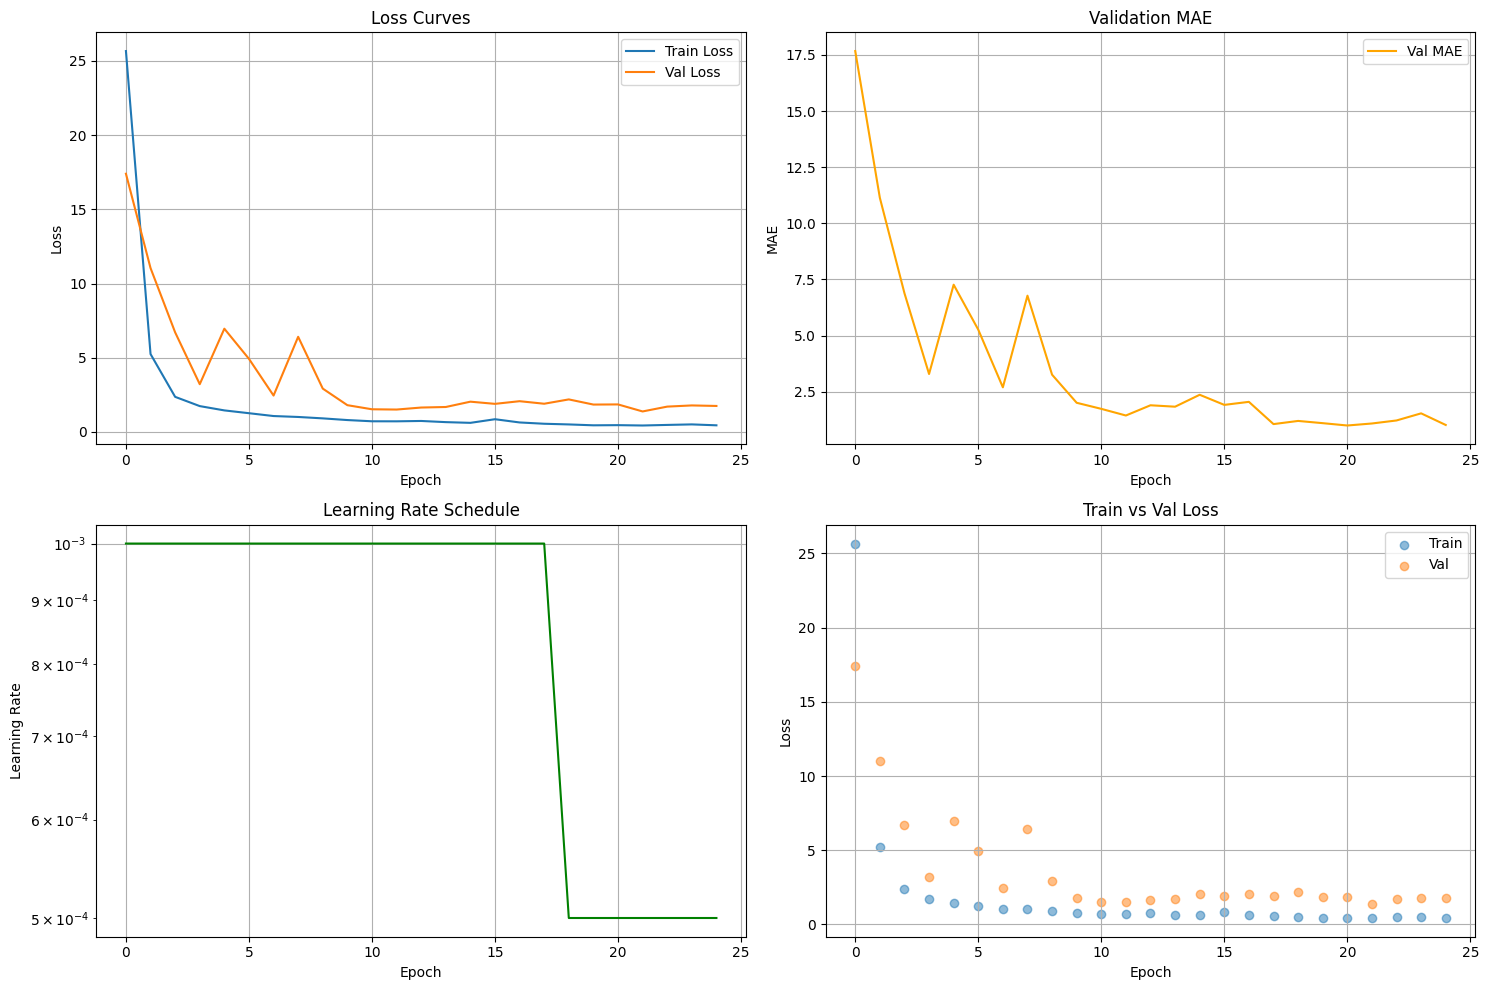

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True)

# MAE
axes[0, 1].plot(history['val_mae'], label='Val MAE', color='orange')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('Validation MAE')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Learning rate
axes[1, 0].plot(history['lr'], color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True)

# Loss comparison
axes[1, 1].scatter(range(len(history['train_loss'])), 
                   history['train_loss'], alpha=0.5, label='Train')
axes[1, 1].scatter(range(len(history['val_loss'])), 
                   history['val_loss'], alpha=0.5, label='Val')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Train vs Val Loss')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150)
plt.show()

# Evaluación Final

In [15]:
# Cargar mejor modelo
checkpoint = torch.load('../models/best_model.pt')
model.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en validación
model.eval()
all_preds = []
all_targets = []
all_elasticities = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        y_hat, eps_hat, _ = model.run(batch, return_parts=True)
        
        all_preds.append(y_hat.cpu())
        y_true = torch.stack(
            [batch[f"log_liters_{i}"] for i in range(n)], dim=1
        )                                                    # (B, n)
        all_targets.append(y_true.cpu())
        all_elasticities.append(eps_hat.cpu())

preds = torch.cat(all_preds).numpy()
targets = torch.cat(all_targets).numpy()
elasticities = torch.cat(all_elasticities).numpy()

# Métricas
mae = np.mean(np.abs(preds - targets))
mse = np.mean((preds - targets) ** 2)
rmse = np.sqrt(mse)
r2 = 1 - (np.sum((targets - preds)**2) / np.sum((targets - targets.mean())**2))

print("Métricas Finales en Validación:")
print(f"  MAE:  {mae:.4f}")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f}")
print(f"\nElasticidades:")
print(f"  Media:    {elasticities.mean():.4f}")
print(f"  Mediana:  {np.median(elasticities):.4f}")
print(f"  Std:      {elasticities.std():.4f}")
print(f"  Min:      {elasticities.min():.4f}")
print(f"  Max:      {elasticities.max():.4f}")
print(f"  % Negativas: {(elasticities < 0).mean() * 100:.4f}%")

Métricas Finales en Validación:
  MAE:  1.0836
  MSE:  2.2222
  RMSE: 1.4907
  R²:   -2.1510

Elasticidades:
  Media:    -10.4720
  Mediana:  1.1740
  Std:      38.7922
  Min:      -172.3143
  Max:      157.7172
  % Negativas: 42.6513%


# Diagnostics

In [16]:
# ── Cross-derivatives symmetry (Slutsky) ─────────────────────────────────
sym_diag = SymmetryElasticityDiagnostics()
sym_penalties = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = sym_diag.run(model=model, batch=batch)
        sym_penalties.append(out.penalty.item())

print(f"Slutsky symmetry residual (val):  {np.mean(sym_penalties):.2e}")
print(f"  (carefull: ~0.00e+00 — guaranteed by A symmetric)")

# ── 2. Schwarz / C² sanity check (∂_k∂_j y_i - ∂_j∂_k y_i) ─────────────
cl_diag = ClosureDiagnostics()
cl_penalties = []

with torch.no_grad():
    batch_sample = next(iter(val_loader))
    batch_sample = {k: v.to(device) for k, v in batch_sample.items()}
    _, _, aux = model.run(batch_sample, return_parts=True)

# u: (B, n_cross, K, K),  Bx: (B, n, K),  dBx: (B, n, K)
u   = aux['u']      # (B, n_cross, K, K)
Bx  = aux['Bx']     # (B, n, K)
dBx = aux['dBx']    # (B, n, K)

pairs = model.head.param_head._pairs   # (2, n_cross)
B, n_cross, K, _ = u.shape
n = model.n

# E_cross[b, i, j] = ∂y_i/∂x_j = Σ_{k,l} u_{ij,kl} * B_k(x_i) * B'_l(x_j)
E_cross = torch.zeros(B, n, n, device=device)
for p in range(n_cross):
    i, j = pairs[0, p].item(), pairs[1, p].item()
    # i < j: ∂y_i/∂x_j
    E_cross[:, i, j] = torch.einsum('bk,bkl,bl->b', Bx[:, i], u[:, p], dBx[:, j])
    # j > i: ∂y_j/∂x_i = same (Slutsky)
    E_cross[:, j, i] = E_cross[:, i, j]

idx = torch.triu_indices(n, n, offset=1)
cross_vals = E_cross[:, idx[0], idx[1]].cpu().numpy().flatten()

print(f"\nElasticidades cruzadas ∂y_i/∂x_j (en precios del batch):")
print(f"  Media:   {cross_vals.mean():.4f}")
print(f"  Std:     {cross_vals.std():.4f}")
print(f"  Min:     {cross_vals.min():.4f}")
print(f"  Max:     {cross_vals.max():.4f}")

Slutsky symmetry residual (val):  0.00e+00
  (carefull: ~0.00e+00 — guaranteed by A symmetric)

Elasticidades cruzadas ∂y_i/∂x_j (en precios del batch):
  Media:   7.5749
  Std:     17.3952
  Min:     -12.4841
  Max:     77.4192


# Analisis Predicciones

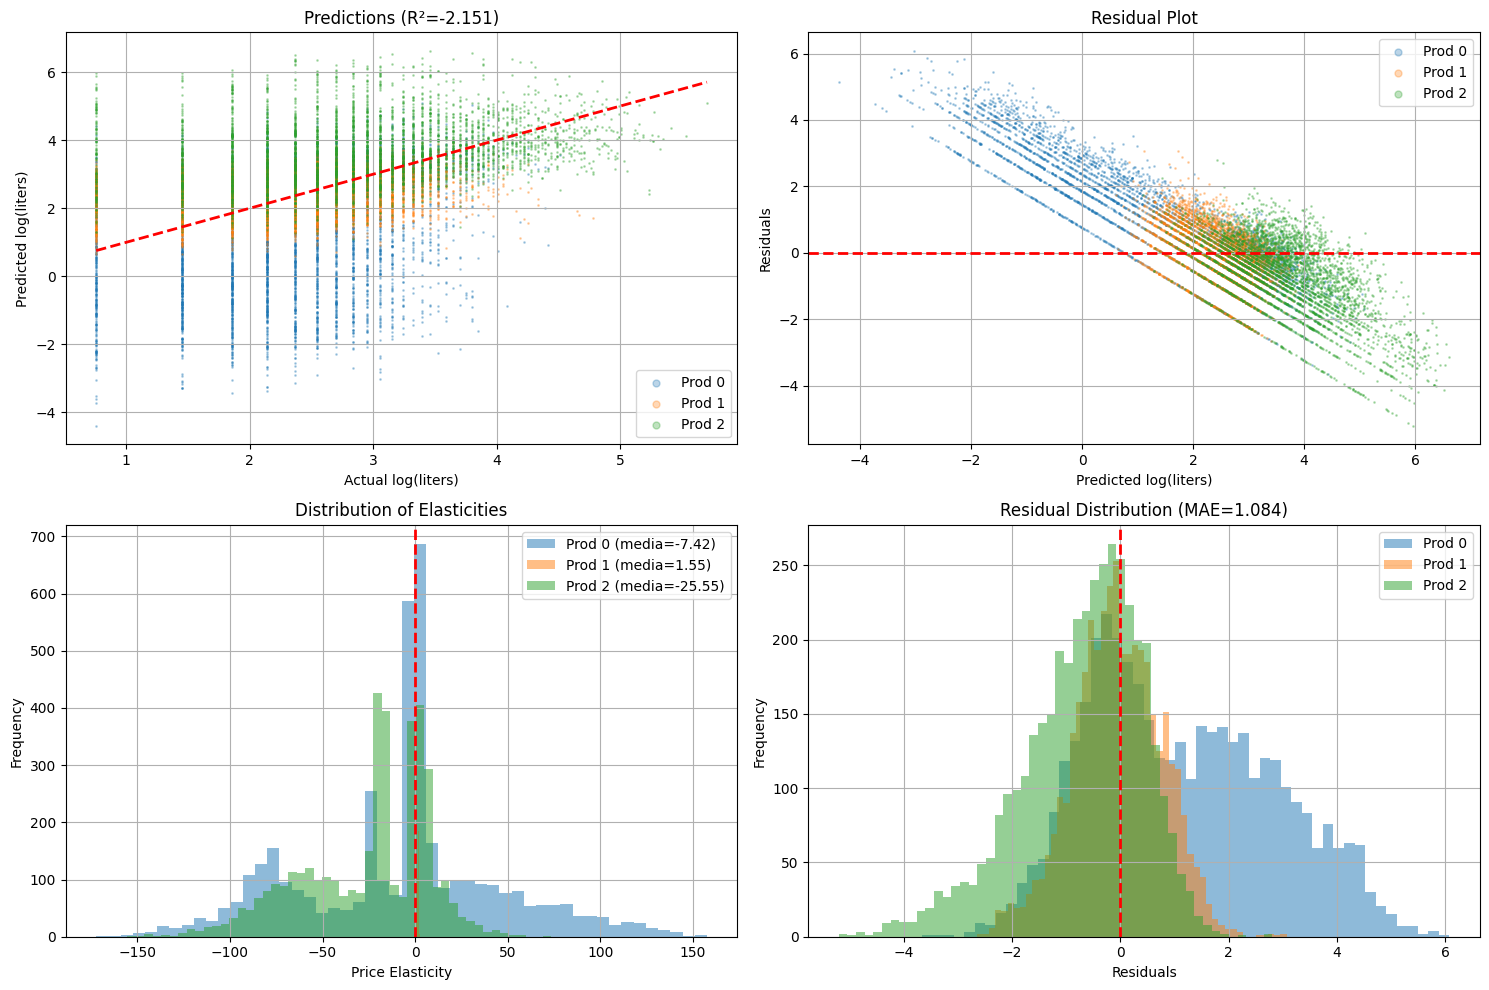


✓ Pipeline completado exitosamente


In [17]:
colors = [cm.tab10(i) for i in range(n)]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Predicted vs Actual — por producto
for i in range(n):
    axes[0, 0].scatter(
        targets[:, i], preds[:, i],
        alpha=0.3, s=1, color=colors[i], label=f'Prod {i}'
    )
axes[0, 0].plot(
    [targets.min(), targets.max()],
    [targets.min(), targets.max()], 'r--', lw=2
)
axes[0, 0].set_xlabel('Actual log(liters)')
axes[0, 0].set_ylabel('Predicted log(liters)')
axes[0, 0].set_title(f'Predictions (R²={r2:.3f})')
axes[0, 0].legend(markerscale=5)
axes[0, 0].grid(True)

# Residual Plot — por producto
residuals = targets - preds   # (N, n)
for i in range(n):
    axes[0, 1].scatter(
        preds[:, i], residuals[:, i],
        alpha=0.3, s=1, color=colors[i], label=f'Prod {i}'
    )
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted log(liters)')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].legend(markerscale=5)
axes[0, 1].grid(True)

# Distribution of Elasticities — por producto
for i in range(n):
    axes[1, 0].hist(
        elasticities[:, i], bins=50, alpha=0.5,
        color=colors[i],
        label=f'Prod {i} (media={elasticities[:, i].mean():.2f})'
    )
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Price Elasticity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Elasticities')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Residual Distribution — por producto
for i in range(n):
    axes[1, 1].hist(
        residuals[:, i], bins=50, alpha=0.5,
        color=colors[i], label=f'Prod {i}'
    )
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Residual Distribution (MAE={mae:.3f})')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('../results/evaluation_plots.png', dpi=150)
plt.show()

print("\n✓ Pipeline completado exitosamente")